In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import math
import time
from datetime import datetime
from IPython.display import HTML
from utilities_func import *   
from torch.utils.data import DataLoader, TensorDataset

In [2]:
from Genetic_utils import *

In [3]:
class MLP_sigmoid(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, pars_W):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = torch.sigmoid
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.activation1 = torch.sigmoid
        self.fc3 = nn.Linear(hidden_size, output_size)
        
        
        if pars_W is not None:
            self.set_weights(pars_W)
        else:
            self.init_weights()
        
        global dict
        if dict['seed'] is not None:
            torch.manual_seed(dict['seed'])
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation1(x)
        x = self.fc3(x)
        return x      
    
    def init_weights(self):
        init.xavier_uniform_(self.fc1.weight)
        init.zeros_(self.fc1.bias)
        init.xavier_uniform_(self.fc2.weight)
        init.zeros_(self.fc2.bias)
    
    def set_weights(self, pars_W):
        with torch.no_grad():
            for param, p in zip(self.parameters(), pars_W):
                param.copy_(torch.tensor(p))
    
    def train_network(self, lr, epochs, X, Y):
        mse_loss = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr)
        
        best_loss = float('inf')  
        epochs_no_improve = 0  
        training_losses = []  
        
        for epoch in range(epochs):
            self.train()
            optimizer.zero_grad()
            output = self(X)
            loss = mse_loss(output, Y)
            training_losses.append(loss.item())
            loss.backward()
            optimizer.step()
            
            print(f"Epoch {epoch+1}/{epochs}, Training Loss: {loss.item():.4f}")
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
        
        # Stopping condizionale
        #     if epochs_no_improve >= patience:
        #         print(f"Early stopping at epoch {epoch+1} due to no improvement.")
        #         break
        
        
        print(f"Training completed. Best Training Loss: {best_loss:.4f}")
        
        return training_losses
    
    
    def validate(self, dataloader, device):
        self.eval() 
        true_preds, num_preds = 0.,0.
        with torch.no_grad():  
            for inputs, targets in dataloader:
                
                inputs, targets = inputs.to(device), targets.to(device)
                
                preds = self(inputs)
                preds = preds.squeeze(dim=1)
                
                
                true_preds += 1 if abs(preds - targets) < 0.05 else 0
                num_preds += 1#targets.shape[0]
        
        avg_acc = true_preds/num_preds
        print(f"Accuracy of the model: {avg_acc*100:.2f}%") 
    
    def plot_training_loss(self, training_losses):

    # Tracciare il grafico della perdita
        plt.plot(training_losses, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()
        plt.show()

In [4]:
  # Training Parameters
dict = {
    'input_size': 1,    # Input size neural network  
    'hidden_size': 6,   # Hidden size neural network
    'output_size': 1,   # Output size neural network
    'epochs': 1000,      # Number of epochs
    'lr': 0.01,         # Learning rate
    'seed': 18,
    'lim_inf': -7,      # Left limit of the domain activation function
    'lim_sup': 7,
    'step_domain': 800
}
             # Seed for weights generation

In [5]:
X=np.linspace(dict['lim_inf'],dict['lim_sup'],dict['step_domain']).reshape(-1,1)
Y=np.sin(X)
X_tensor = torch.tensor(X,dtype=torch.float32)
Y_tensor = torch.tensor(Y,dtype=torch.float32)

800
Epoch 1/1000, Training Loss: 0.6983
Epoch 2/1000, Training Loss: 0.6551
Epoch 3/1000, Training Loss: 0.6168
Epoch 4/1000, Training Loss: 0.5835
Epoch 5/1000, Training Loss: 0.5547
Epoch 6/1000, Training Loss: 0.5302
Epoch 7/1000, Training Loss: 0.5098
Epoch 8/1000, Training Loss: 0.4931
Epoch 9/1000, Training Loss: 0.4799
Epoch 10/1000, Training Loss: 0.4698
Epoch 11/1000, Training Loss: 0.4626
Epoch 12/1000, Training Loss: 0.4578
Epoch 13/1000, Training Loss: 0.4551
Epoch 14/1000, Training Loss: 0.4541
Epoch 15/1000, Training Loss: 0.4544
Epoch 16/1000, Training Loss: 0.4556
Epoch 17/1000, Training Loss: 0.4573
Epoch 18/1000, Training Loss: 0.4593
Epoch 19/1000, Training Loss: 0.4611
Epoch 20/1000, Training Loss: 0.4626
Epoch 21/1000, Training Loss: 0.4637
Epoch 22/1000, Training Loss: 0.4643
Epoch 23/1000, Training Loss: 0.4643
Epoch 24/1000, Training Loss: 0.4639
Epoch 25/1000, Training Loss: 0.4630
Epoch 26/1000, Training Loss: 0.4617
Epoch 27/1000, Training Loss: 0.4603
Epoch 

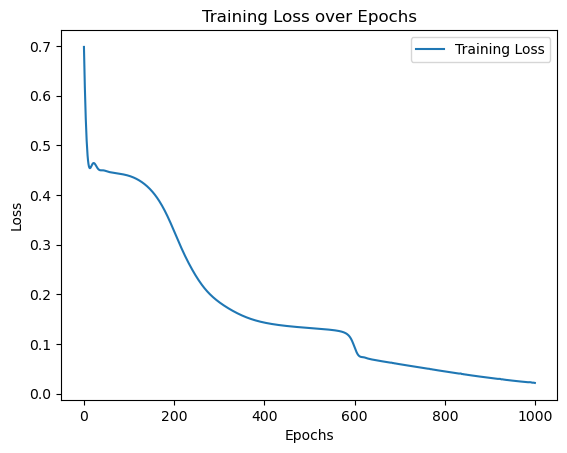

Accuracy of the model: 50.38%


In [6]:
val_data = TensorDataset(X_tensor, Y_tensor)
val_loader = DataLoader(val_data, batch_size=1, shuffle=False)

print(len(val_loader))

model = MLP_sigmoid(dict['input_size'], dict['hidden_size'], dict['output_size'], None)

# Esegui l'allenamento
training_losses = model.train_network(dict['lr'], dict['epochs'], X_tensor, Y_tensor)

# Supponiamo di avere un dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.plot_training_loss(training_losses)

# Validazione del modello
model.validate(val_loader, device)


Text(0.5, 1.0, 'Training Loss over Epochs')

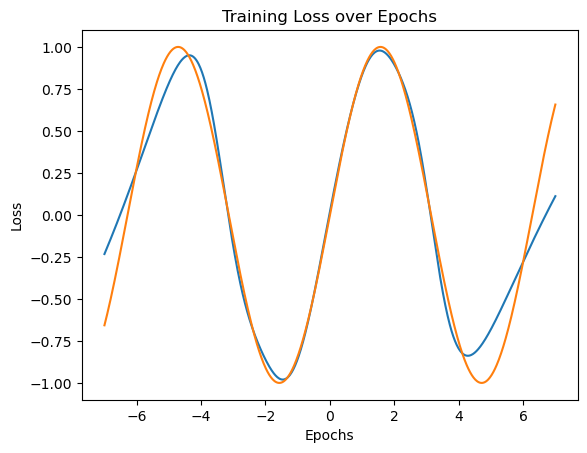

In [7]:
# Tracciare il grafico della perdita
plt.plot(X_tensor, model(X_tensor).detach().numpy() )
plt.plot(X_tensor, Y_tensor)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")

In [8]:
test_genome = [0.0, 2.1, 1.2, 0.6, 0.6, 0.6, 1.2, 2.1, 2.4, 2.4, 2.4, 1.5, 1.8, 2.1, 0.0, 0.9, 1.2, 0.6, 0.3, 0.6, 1.5,
               2.1, 2.7, 2.4, 2.4, 1.8, 2.1, 2.7]
rete_test = Individual(test_genome, 1, 6, 1)
rete_test.training(0.01, 1000, X_tensor, Y_tensor, patience = 5, early_stopping=False)

Text(0.5, 1.0, 'Training Loss over Epochs')

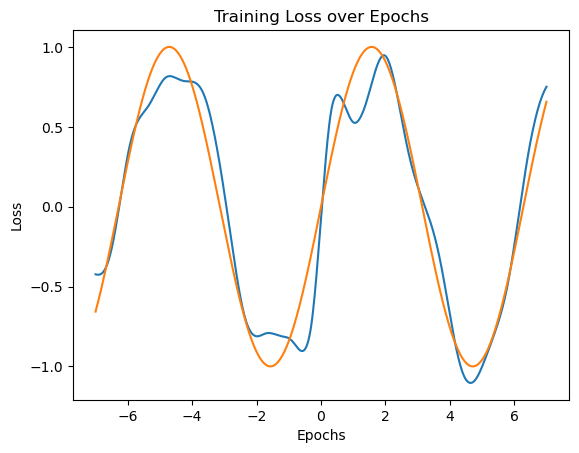

In [9]:
# Tracciare il grafico della perdita
plt.plot(X_tensor, rete_test.network(X_tensor).detach().numpy() )
plt.plot(X_tensor, Y_tensor)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Comparison output Dataset and output Network")

In [10]:
rete_test.validate(val_loader, device)

Accuracy of the model: 30.50%


In [11]:
best_individual = min(net_pop, key=lambda x: x.score)
best_individual_loss = best_individual.score  # Questo è il miglior punteggio (loss)


NameError: name 'net_pop' is not defined

In [ ]:
final_loss_mlp_sigmoid = training_losses[-1]  # Ultima perdita della rete MLP sigmoide


In [ ]:
# Curva di perdita per la MLP Custom
plt.plot(Mean_sim, label="Algoritmo Genetico (MSE)")

# Curva di perdita per la MLP Sigmoide
plt.plot(training_losses, label="MLP Sigmoide (MSE)")

plt.xlabel("Epoche")
plt.ylabel("Perdita (Loss)")
plt.title("Confronto tra Algoritmo Genetico e MLP Sigmoide")
plt.legend()
plt.show()

print(f"Perdita finale MLP Custom (Algoritmo Genetico): {best_individual_loss}")
print(f"Perdita finale MLP Sigmoide: {final_loss_mlp_sigmoid}")
